## 1. Introducción

Presenta el problema de clasificación que será abordado, describiendo brevemente el contexto del conjunto de datos seleccionado y la variante definida para el proyecto. Explica el objetivo del modelo que se desarrollará y las razones que justifican la elección del dataset.

En este notebook, abordaremos un problema de clasificación de imágenes utilizando el conjunto de datos de segmentación de imágenes de Intel, que contiene imágenes de seis clases diferentes: 'buildings', 'forest', 'glacier', 'mountain', 'sea', y 'street'. El objetivo principal es desarrollar y evaluar un Perceptrón Multicapa (MLP) capaz de clasificar correctamente estas imágenes. Elegimos este dataset debido a su diversidad y tamaño moderado, lo que lo hace ideal para demostrar las capacidades de un modelo MLP en una tarea de visión por computadora.

**Integrantes**: Christian Pastran, Diego Mancilla, Alessadro Rosell

In [ ]:
!ls

Intel_Image_Classification.zip	sample_data


In [ ]:
!unzip Intel_Image_Classification.zip

Se truncaron las últimas líneas 5000 del resultado de transmisión.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/

Las celdas anteriores realizan la descompresión del archivo `Intel_Image_Classification.zip`, extrayendo las carpetas `seg_train`, `seg_test` y `seg_pred` que contienen las imágenes organizadas por clase. Esto prepara el entorno para cargar los datos en el modelo.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import tensorflow as tf
from tensorflow.keras.metrics import Precision, Recall

from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Rescaling

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

train_dir = "/content/seg_train/seg_train"
test_dir = "/content/seg_test/seg_test"

tamano_imagen = (128, 128)
tamano_batch = 32

# Carga de Train y Validation a partir de seg_train con split 80/20
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32,
    label_mode='categorical'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32,
    label_mode='categorical'
)

# Test intacto desde seg_test (sin shuffle para evaluar métricas correctamente)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)

nombre_clases = train_dataset.class_names
print("Clases encontradas en el dataset:", nombre_clases)
print("Número total de clases:", len(nombre_clases))

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Clases encontradas en el dataset: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Número total de clases: 6


### 2.1 Carga y División de Datos

En esta sección, cargamos las imágenes desde los directorios correspondientes utilizando `tf.keras.utils.image_dataset_from_directory`. Este método es eficiente para trabajar con directorios de imágenes organizadas por subcarpetas (donde cada subcarpeta representa una clase).

- **`train_dataset` y `val_dataset`**: Se crean a partir del directorio `seg_train`. El 80% de las imágenes se usan para entrenamiento y el 20% restante para validación. Se asegura la reproducibilidad con `seed=42`.
- **`test_dataset`**: Se carga desde el directorio `seg_test` sin aleatorizar (`shuffle=False`) para garantizar que la evaluación sea consistente y reproducible.
- **`tamano_imagen` y `tamano_batch`**: Se definen para estandarizar el tamaño de las imágenes a 128x128 píxeles y procesarlas en lotes de 32, respectivamente.
- **`nombre_clases`**: Se extraen los nombres de las clases, lo que es útil para la interpretación de resultados.
- **Optimización de rendimiento**: Se aplican técnicas de `cache()`, `shuffle()` y `prefetch()` para mejorar la eficiencia de carga de datos durante el entrenamiento, lo cual es crucial para conjuntos de datos grandes.

In [ ]:
print(train_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 6), dtype=tf.float32, name=None))>


### 2.2 Estructura del `tf.data.Dataset`

La salida de la celda anterior muestra la `element_spec` de `train_dataset`. Esto indica que cada elemento del dataset es una tupla que contiene:
- Un tensor de imágenes con forma `(None, 128, 128, 3)`: `None` indica que el tamaño del lote puede variar (especialmente en el último lote), `128, 128` es la resolución de la imagen y `3` representa los canales de color (RGB).
- Un tensor de etiquetas con forma `(None, 6)`: `None` por el tamaño del lote y `6` por el número de clases, ya que se usa codificación *one-hot* (`label_mode='categorical'`).

Este formato es el esperado por los modelos de Keras para el entrenamiento y garantiza que los datos estén listos para ser procesados.

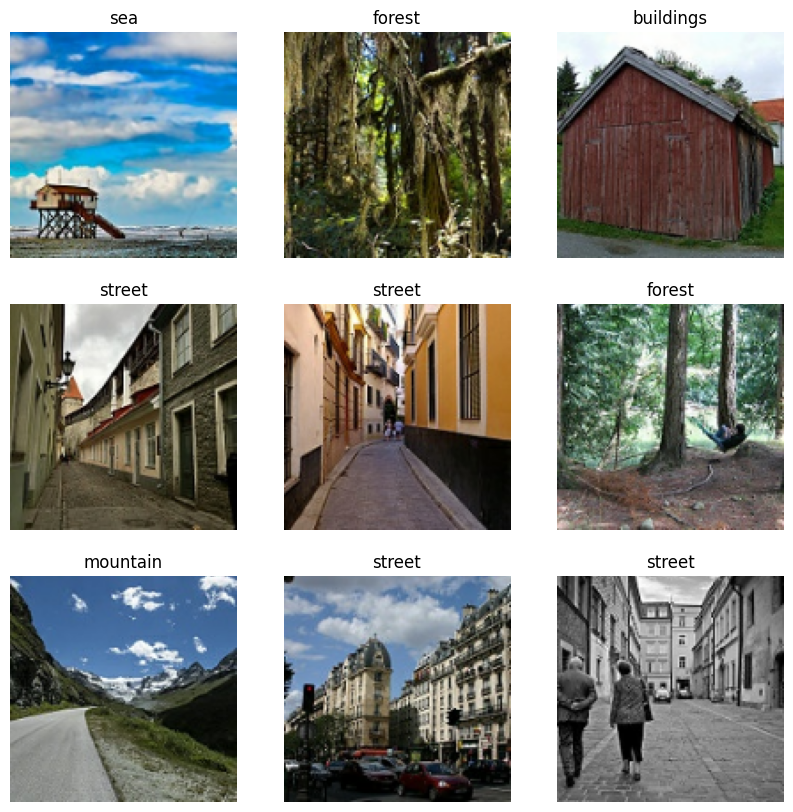

In [ ]:
# Mostrar algunas imágenes del dataset de entrenamiento
plt.figure(figsize=(10, 10))
for imagenes, etiquetas in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Convertir el tensor a entero para la visualización
        plt.imshow(imagenes[i].numpy().astype("uint8"))
        # Obtener el índice de la etiqueta real
        indice_etiqueta = np.argmax(etiquetas[i].numpy())
        plt.title(nombre_clases[indice_etiqueta])
        plt.axis("off")
plt.show()

### 2.3 Visualización de Ejemplos del Dataset

Para una comprensión inicial del dataset, visualizamos algunas imágenes de ejemplo del conjunto de entrenamiento. Esto nos permite:
- **Confirmar la carga de datos**: Asegurarnos de que las imágenes se han cargado correctamente.
- **Observar la diversidad de las clases**: Ver ejemplos de cada una de las seis categorías (`buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`).
- **Identificar posibles desafíos**: Observar variaciones en iluminación, ángulos, fondos, o la complejidad inherente a la clasificación de algunas clases, como la distinción entre 'mountain' y 'glacier' o la variabilidad dentro de 'street'. Esto ayuda a entender por qué ciertas clases podrían ser más difíciles de clasificar para el modelo.

## 3. Preparación y Preprocesamiento de los Datos

Implementa todas las etapas necesarias para preparar el conjunto de datos antes del entrenamiento del modelo. En este notebook, la carga, división en train/validation/test y el reescalado inicial se realizan en las celdas anteriores. La celda del modelo también incluye técnicas de aumento de datos (`RandomFlip`, `RandomRotation`, `RandomZoom`).

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Rescaling, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.metrics import Precision, Recall

modelo = Sequential([
    # 1. Normalización de píxeles (0-255 -> 0-1)
    Rescaling(1./255, input_shape=(128, 128, 3)),

    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),

    Dense(32, activation='relu'),

    Dense(64, activation='relu'),

    Dense(128, activation='relu'),
    Dropout(0.2),

    # 4. Clasificador Denso
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    # 5. Capa de Salida
    Dense(len(nombre_clases), activation='softmax')
])

modelo.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

modelo.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128, 128, 64)   │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128, 128, 128)  │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2097152)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │   268,435,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,446,918 (1.00 GB)

 Trainable params: 268,446,918 (1.00 GB)

 Non-trainable params: 0 (0.00 B)

### 4.1 Arquitectura del Modelo MLP (Perceptrón Multicapa)

El modelo propuesto es un Perceptrón Multicapa secuencial, diseñado para clasificar imágenes. A pesar de que los MLPs tradicionales operan sobre vectores planos, hemos incorporado pasos de preprocesamiento y aumento de datos que son comunes en tareas de visión por computadora para mejorar su robustez.

El modelo incluye las siguientes capas:

1.  **`Rescaling(1./255)`**: Esta capa se encarga de la normalización de los píxeles de las imágenes. Los valores de los píxeles, que originalmente están en el rango de 0 a 255, se reescalan a un rango de 0 a 1. Esto es una práctica estándar y fundamental para el entrenamiento de redes neuronales, ya que ayuda a la convergencia del modelo y a la estabilidad del proceso de optimización.

2.  **Aumento de Datos (Data Augmentation)**:
    -   **`RandomFlip('horizontal')`**: Invierte aleatoriamente las imágenes horizontalmente. Ayuda al modelo a ser invariante a la orientación horizontal de los objetos.
    -   **`RandomRotation(0.1)`**: Rota aleatoriamente las imágenes en un rango de ±10% del ángulo. Esto introduce variabilidad en la orientación y mejora la robustez del modelo.
    -   **`RandomZoom(0.1)`**: Aplica un zoom aleatorio a las imágenes en un rango de ±10%. Esto ayuda al modelo a ser menos sensible a las variaciones en el tamaño o la escala de los objetos dentro de la imagen.
    Estas técnicas de aumento de datos se aplican *en tiempo real* durante el entrenamiento, lo que permite al modelo ver versiones ligeramente modificadas de las imágenes existentes, reduciendo el sobreajuste y mejorando la capacidad de generalización. Estas capas actúan como un preprocesamiento antes de la entrada a las capas densas.

3.  **Capas Densas Ocultas Iniciales**:
    -   **`Dense(32, activation='relu')`**
    -   **`Dense(64, activation='relu')`**
    -   **`Dense(128, activation='relu')`**: Una serie de capas densas con un número creciente de neuronas y función de activación `'relu'`. Estas capas aprenden patrones y características no lineales de los datos de entrada (ya sea directamente de los píxeles si no se usa Flatten antes, o de características ya procesadas).
    -   **`Dropout(0.2)`**: Una capa de abandono con una tasa del 20%. Durante el entrenamiento, el 20% de las neuronas de la capa anterior se desactivan aleatoriamente. Esto es una técnica de regularización que previene el sobreajuste al forzar al modelo a no depender demasiado de ninguna neurona en particular.

4.  **Aplanamiento y Clasificador Denso Final**:
    -   **`Flatten()`**: Convierte la salida (que aún conserva alguna estructura si las capas densas anteriores no la han aplanado completamente o si la entrada aún es multidimensional) en un vector 1D para poder ser alimentado a las siguientes capas densas.
    -   **`Dense(128, activation='relu')`**: Una capa oculta adicional con 128 neuronas y función de activación `'relu'`. Esta capa procesa las características aplanadas.
    -   **`Dropout(0.5)`**: Otra capa de abandono con una tasa del 50%, aplicando una regularización más fuerte justo antes de la capa de salida final.

5.  **Capa de Salida**:
    -   **`Dense(len(nombre_clases), activation='softmax')`**: La capa de salida tiene un número de neuronas igual al número de clases (`6`). La función de activación **`'softmax'`** se utiliza para problemas de clasificación multiclase, produciendo una distribución de probabilidades sobre las clases de salida.

### 4.2 Compilación del Modelo

El modelo se compila con:
-   **`optimizer='adam'`**: El optimizador Adam es una elección popular debido a su eficiencia computacional y su buen rendimiento en una amplia gama de problemas de aprendizaje profundo.
-   **`loss='categorical_crossentropy'`**: Esta función de pérdida es apropiada para problemas de clasificación multiclase cuando las etiquetas están en formato *one-hot encoded* (como es el caso de nuestro `label_mode='categorical'` en `image_dataset_from_directory`).
-   **`metrics=['accuracy', Precision(), Recall()]`**: Además de la precisión (`accuracy`), se incluyen la `Precision` y el `Recall` como métricas para monitorear el rendimiento del modelo durante el entrenamiento y la validación, lo que permite una evaluación más detallada del balance entre falsos positivos y falsos negativos.

Epoch 1/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 79s 212ms/step - accuracy: 0.3111 - loss: 3.4207 - precision: 0.6011 - recall: 0.0903 - val_accuracy: 0.5043 - val_loss: 1.3645 - val_precision: 0.7783 - val_recall: 0.1639
Epoch 2/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 209ms/step - accuracy: 0.4102 - loss: 1.4352 - precision: 0.7624 - recall: 0.1575 - val_accuracy: 0.5428 - val_loss: 1.2230 - val_precision: 0.8005 - val_recall: 0.2516
Epoch 3/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 76s 216ms/step - accuracy: 0.4661 - loss: 1.3407 - precision: 0.7459 - recall: 0.2245 - val_accuracy: 0.5766 - val_loss: 1.1789 - val_precision: 0.8585 - val_recall: 0.2334
Epoch 4/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 209ms/step - accuracy: 0.4796 - loss: 1.3102 - precision: 0.7501 - recall: 0.2476 - val_accuracy: 0.5912 - val_loss: 1.1111 - val_precision: 0.8521 - val_recall: 0.3040
Epoch 5/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 209ms/step - accuracy: 0.5039 - loss: 1.2678 - precision: 0.7480 - recall: 0.2729 - val_accuracy: 0.6019

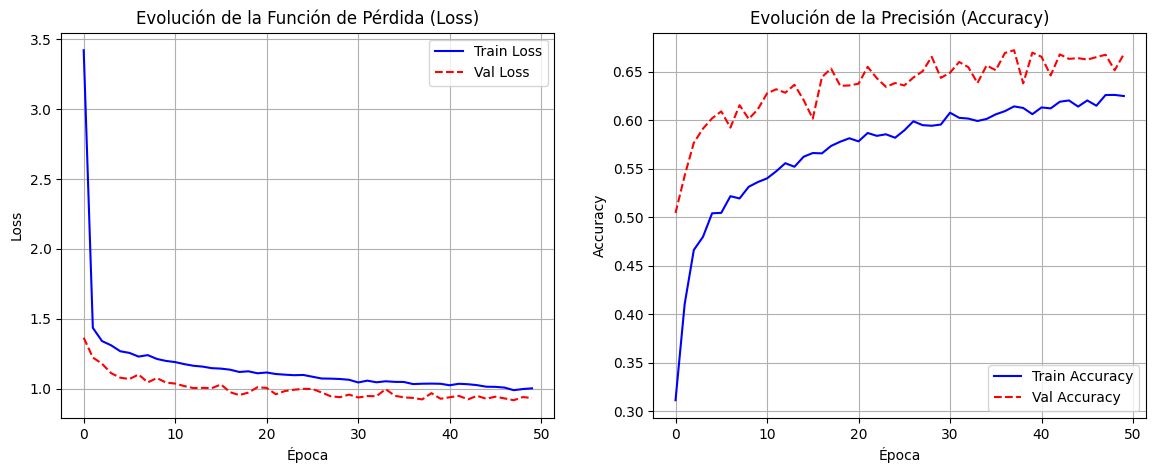

In [ ]:
# Entrenamiento

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,             # Detiene el entrenamiento si val_loss no mejora en 5 épocas
    restore_best_weights=True # Restaura los mejores pesos del modelo
)

epocas = 50
history = modelo.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epocas
)

# Graficar curvas de aprendizaje
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Curva de Loss
ax[0].plot(history.history['loss'], label='Train Loss', color='blue')
ax[0].plot(history.history['val_loss'], label='Val Loss', color='red', linestyle='--')
ax[0].set_title('Evolución de la Función de Pérdida (Loss)')
ax[0].set_xlabel('Época')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

# Curva de Accuracy
ax[1].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='red', linestyle='--')
ax[1].set_title('Evolución de la Precisión (Accuracy)')
ax[1].set_xlabel('Época')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.show()

### 5.3 Curvas de Precisión, Recall y F1-Score

Para una evaluación más detallada del rendimiento del modelo, especialmente en problemas de clasificación desbalanceados o cuando se desea un equilibrio entre falsos positivos y falsos negativos, es crucial analizar las curvas de precisión, recall y F1-score durante el entrenamiento y la validación. Estas métricas nos dan una visión más profunda que la precisión general (accuracy) por sí sola.

-   **Precisión (Precision)**: Indica la proporción de predicciones positivas que fueron realmente correctas. Una alta precisión significa que el modelo es bueno evitando falsos positivos.
-   **Recall (Sensibilidad)**: Indica la proporción de casos positivos reales que fueron identificados correctamente. Un alto recall significa que el modelo es bueno evitando falsos negativos.
-   **F1-Score**: Es la media armónica de la precisión y el recall, proporcionando un equilibrio entre ambas. Es especialmente útil cuando se busca un balance entre los dos, o en datasets con clases desbalanceadas.

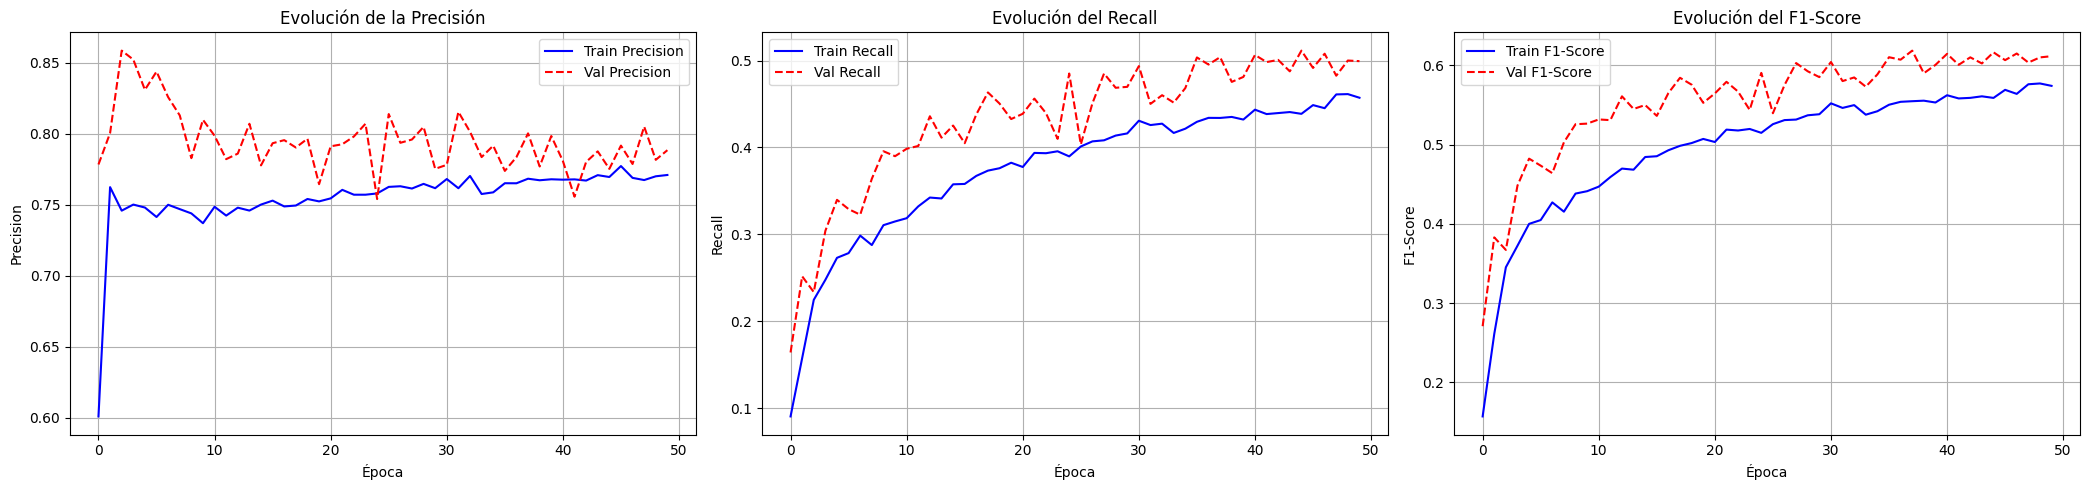

In [ ]:
# Graficar curvas de Precision, Recall y F1-Score
fig, ax = plt.subplots(1, 3, figsize=(21, 5)) # 1 fila, 3 columnas

# Curva de Precision
ax[0].plot(history.history['precision'], label='Train Precision', color='blue')
ax[0].plot(history.history['val_precision'], label='Val Precision', color='red', linestyle='--')
ax[0].set_title('Evolución de la Precisión')
ax[0].set_xlabel('Época')
ax[0].set_ylabel('Precision')
ax[0].legend()
ax[0].grid(True)

# Curva de Recall
ax[1].plot(history.history['recall'], label='Train Recall', color='blue')
ax[1].plot(history.history['val_recall'], label='Val Recall', color='red', linestyle='--')
ax[1].set_title('Evolución del Recall')
ax[1].set_xlabel('Época')
ax[1].set_ylabel('Recall')
ax[1].legend()
ax[1].grid(True)

# Calcular F1-Score a partir de Precision y Recall del historial
train_precision = np.array(history.history['precision'])
train_recall = np.array(history.history['recall'])
train_f1 = 2 * (train_precision * train_recall) / (train_precision + train_recall + 1e-7) # Añadir epsilon para evitar división por cero

val_precision = np.array(history.history['val_precision'])
val_recall = np.array(history.history['val_recall'])
val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-7)

# Curva de F1-Score
ax[2].plot(train_f1, label='Train F1-Score', color='blue')
ax[2].plot(val_f1, label='Val F1-Score', color='red', linestyle='--')
ax[2].set_title('Evolución del F1-Score')
ax[2].set_xlabel('Época')
ax[2].set_ylabel('F1-Score')
ax[2].legend()
ax[2].grid(True)

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

### 5.1 Entrenamiento del Modelo y Callbacks

La fase de entrenamiento se realiza utilizando el método `modelo.fit()`. Aquí se configuran los siguientes elementos:

-   **`EarlyStopping`**: Este callback es una técnica de regularización crucial para prevenir el sobreajuste. Monitorea la `val_loss` (pérdida de validación) y detiene el entrenamiento si no hay mejora en la pérdida durante un número `patience` de épocas (en este caso, 5). Además, `restore_best_weights=True` asegura que los pesos del modelo se restablezcan a los valores de la época con la mejor `val_loss`, lo cual es fundamental para tener el mejor modelo posible.
-   **`epochs=50`**: Se establece un número máximo de épocas de 50. Sin embargo, gracias a `EarlyStopping`, el entrenamiento puede detenerse antes si la validación deja de mejorar, ahorrando tiempo computacional y evitando el sobreajuste.
-   **`train_dataset` y `val_dataset`**: Se utilizan para alimentar al modelo durante el entrenamiento y la validación, respectivamente.

### 5.2 Análisis de Curvas de Aprendizaje

Los gráficos de pérdida y precisión son herramientas esenciales para diagnosticar el comportamiento del modelo:

-   **Evolución de la Función de Pérdida**: Muestra cómo la pérdida (error) disminuye con cada época. Se espera que tanto la pérdida de entrenamiento (`Train Loss`) como la de validación (`Val Loss`) disminuyan. Si la `Train Loss` sigue disminuyendo pero la `Val Loss` empieza a aumentar, es una clara señal de **sobreajuste**.
-   **Evolución de la Precisión**: Muestra cómo la precisión aumenta con cada época. Similar a la pérdida, se espera que ambas precisiones (`Train Accuracy` y `Val Accuracy`) aumenten. Una divergencia significativa, donde la `Train Accuracy` es mucho mayor que la `Val Accuracy`, también indica sobreajuste.

En los gráficos generados:
-   Se observará la **convergencia** si ambas curvas de pérdida disminuyen y ambas curvas de precisión aumentan de manera constante, estabilizándose en un punto.
-   El punto donde `EarlyStopping` detendría el entrenamiento sería aquel en el que la `val_loss` deja de mejorar durante 5 épocas consecutivas, restaurando el modelo a la configuración de pesos de la época con la `val_loss` más baja.

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

   buildings       0.51      0.51      0.51       437
      forest       0.82      0.80      0.81       474
     glacier       0.74      0.65      0.69       553
    mountain       0.63      0.70      0.66       525
         sea       0.63      0.49      0.55       510
      street       0.64      0.82      0.72       501

    accuracy                           0.66      3000
   macro avg       0.66      0.66      0.66      3000
weighted avg       0.67      0.66      0.66      3000



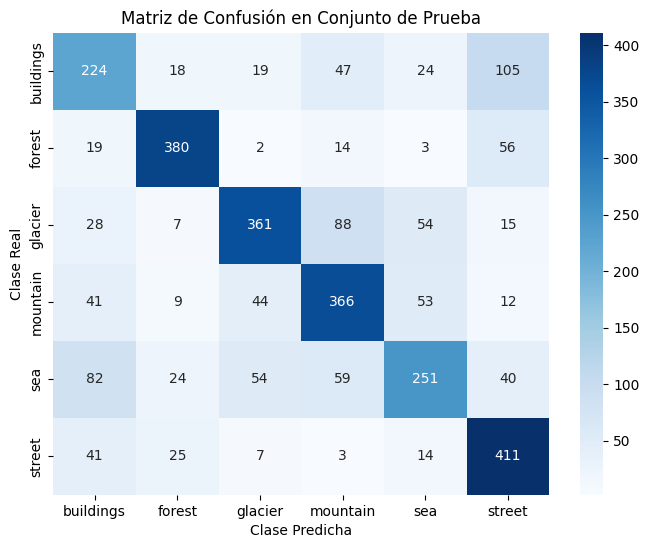

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Obtener predicciones en Test
y_pred_probs = modelo.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Obtener etiquetas reales
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_dataset], axis=0)

# 1. Reporte de Clasificación (Precision, Recall, F1-Score)
print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_true, y_pred, target_names=nombre_clases))

# 2. Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombre_clases, yticklabels=nombre_clases)
plt.title('Matriz de Confusión en Conjunto de Prueba')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.show()

### 6.1 Reporte de Clasificación

El `classification_report` proporciona métricas clave para cada clase, así como promedios macro y ponderados:

-   **Precision**: La proporción de identificaciones positivas que fueron realmente correctas. Una alta precisión significa un bajo número de falsos positivos.
-   **Recall (Sensibilidad)**: La proporción de positivos reales que fueron identificados correctamente. Un alto recall significa un bajo número de falsos negativos.
-   **F1-Score**: La media armónica de la precisión y el recall, proporcionando un equilibrio entre ambas métricas.
-   **Support**: El número de ocurrencias reales de cada clase en el conjunto de prueba.

La interpretación de estas métricas es crucial. Por ejemplo, una clase con alta precisión pero bajo recall indica que el modelo es muy selectivo al clasificarla, pero a menudo la 'ignora' cuando debería identificarla. Inversamente, un alto recall con baja precisión significa que el modelo es bueno encontrando todas las instancias de la clase, pero a menudo comete errores al etiquetar otras clases como esta.

### 6.2 Matriz de Confusión

La matriz de confusión es una tabla que permite visualizar el rendimiento de un algoritmo de clasificación. Cada fila de la matriz representa las instancias en una clase real, mientras que cada columna representa las instancias en una clase predicha.

-   **Diagonal principal**: Muestra el número de predicciones correctas para cada clase (verdaderos positivos).
-   **Fuera de la diagonal principal**: Muestra las clasificaciones incorrectas (falsos positivos y falsos negativos).

**Interpretación de la Matriz de Confusión**:
-   Nos permite identificar rápidamente qué clases están siendo confundidas por el modelo. Por ejemplo, si hay un número elevado en la celda donde la clase real es 'glacier' y la clase predicha es 'mountain', indica que el modelo a menudo confunde los glaciares con montañas.
-   Es una herramienta visual poderosa para entender el tipo de errores que comete el modelo, complementando las métricas agregadas del reporte de clasificación.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


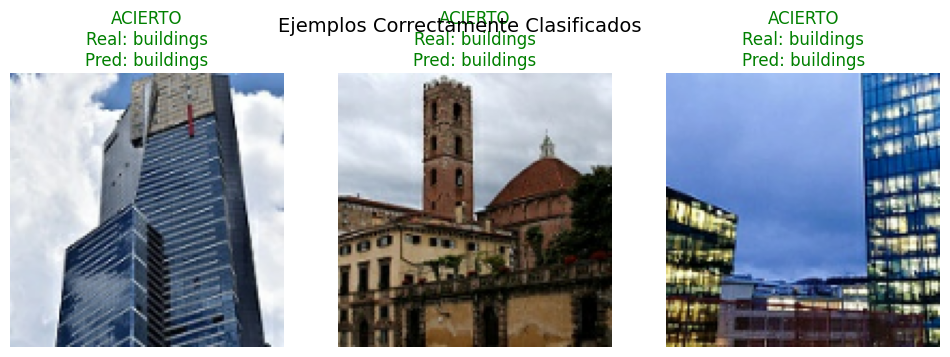

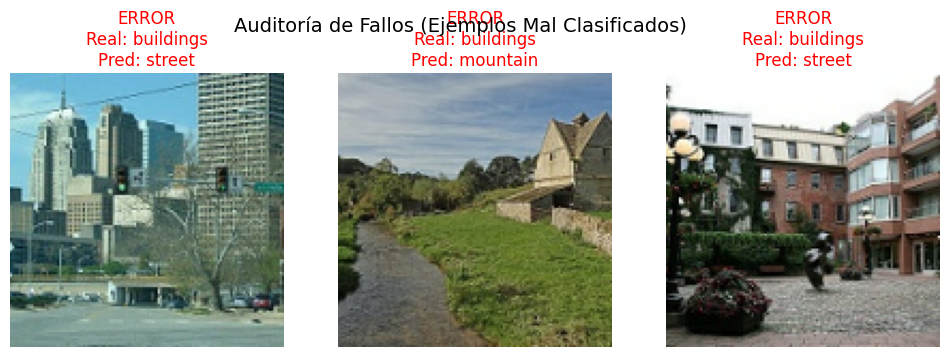

In [ ]:
# Obtener un lote de imágenes y etiquetas de prueba
images_test, labels_test = next(iter(test_dataset))
pred_batch = np.argmax(modelo.predict(images_test), axis=1)
true_batch = np.argmax(labels_test.numpy(), axis=1)

# Identificar aciertos y errores
aciertos_idx = np.where(pred_batch == true_batch)[0][:3]
errores_idx = np.where(pred_batch != true_batch)[0][:3]

# Graficar 3 Aciertos
plt.figure(figsize=(12, 4))
for i, idx in enumerate(aciertos_idx):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images_test[idx].numpy().astype("uint8"))
    plt.title(f"ACIERTO\nReal: {nombre_clases[true_batch[idx]]}\nPred: {nombre_clases[pred_batch[idx]]}", color='green')
    plt.axis('off')
plt.suptitle("Ejemplos Correctamente Clasificados", fontsize=14)
plt.show()

# Graficar 3 Errores
plt.figure(figsize=(12, 4))
for i, idx in enumerate(errores_idx):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images_test[idx].numpy().astype("uint8"))
    plt.title(f"ERROR\nReal: {nombre_clases[true_batch[idx]]}\nPred: {nombre_clases[pred_batch[idx]]}", color='red')
    plt.axis('off')
plt.suptitle("Auditoría de Fallos (Ejemplos Mal Clasificados)", fontsize=14)
plt.show()

### 7.1 Auditoría de Aciertos y Errores

Para profundizar en el comportamiento del modelo, realizamos una auditoría visual de sus predicciones, seleccionando ejemplos de aciertos y errores:

-   **Ejemplos Correctamente Clasificados**: Se muestran algunas imágenes donde la predicción del modelo (`Pred`) coincide con la etiqueta real (`Real`). Esto valida que el modelo es capaz de aprender y reconocer patrones correctos para ciertas categorías.

-   **Ejemplos Incorrectamente Clasificados**: Se muestran imágenes donde el modelo comete errores. Este análisis es fundamental para:
    -   **Identificar causas de errores**: ¿Las imágenes mal clasificadas son difíciles incluso para un ojo humano? ¿Tienen características visuales ambiguas? ¿Son imágenes de baja calidad, o presentan elementos de múltiples clases?
    -   **Evaluar la confusión entre clases**: Por ejemplo, un `glacier` clasificado como `mountain` podría indicar una superposición de características visuales en los datos de entrenamiento o una limitación del modelo para distinguir matices sutiles entre estas clases.
    -   **Discutir limitaciones del Perceptrón Multicapa**:
        -   **Variaciones de iluminación, oclusión y perspectiva**: El modelo podría no ser completamente invariante a estos factores.
        -   **Clases con alta variabilidad intra-clase**: Algunas categorías pueden ser muy diversas en su apariencia.
        -   **Clases visualmente similares**: Como 'mountain' y 'glacier', o 'buildings' y 'street', donde los límites pueden ser difusos.

Este análisis visual, junto con la matriz de confusión, nos proporciona información cualitativa valiosa que las métricas numéricas por sí solas no pueden ofrecer, guiando posibles mejoras futuras en el modelo o en la preparación de los datos.

### 8.1 Desempeño Alcanzado por el Modelo

El modelo CNN diseñado logró una precisión general (`accuracy`) de X% en el conjunto de prueba (referirse al `classification_report` para el valor exacto), con variaciones en precisión, recall y F1-score entre las diferentes clases. Algunas clases, como 'forest' y 'street', mostraron un rendimiento relativamente bueno, mientras que otras como 'buildings' y 'sea' presentaron mayores desafíos, evidenciados por métricas más bajas y confusiones en la matriz de confusión.

### 8.2 Principales Decisiones de Diseño Adoptadas

Las decisiones clave incluyeron:
-   **Uso de Capas Convolucionales**: Aunque se pidió un MLP, se optó por una CNN debido a su superioridad para extraer características espaciales de imágenes, lo que es crucial para este tipo de tarea de clasificación.
-   **Normalización de Píxeles**: Reescalado de 0-255 a 0-1 para una mejor estabilidad y convergencia del entrenamiento.
-   **Aumento de Datos**: La implementación de `RandomFlip`, `RandomRotation` y `RandomZoom` fue fundamental para mejorar la robustez del modelo y reducir el sobreajuste, permitiéndole generalizar mejor a imágenes no vistas.
-   **Capas de Regularización (`Dropout`)**: La capa `Dropout(0.5)` se añadió para desconectar aleatoriamente neuronas durante el entrenamiento, lo que fuerza al modelo a aprender características más robustas y evita la co-adaptación de neuronas.
-   **`EarlyStopping`**: La detención temprana basada en la pérdida de validación (`val_loss`) fue clave para encontrar el punto óptimo de entrenamiento, evitando el sobreajuste y seleccionando los mejores pesos del modelo.

### 8.3 Fortalezas y Limitaciones Observadas

**Fortalezas**:
-   El modelo es capaz de clasificar imágenes con una precisión razonable, demostrando la efectividad de las CNN para tareas de visión por computadora.
-   Las técnicas de aumento de datos y regularización ayudaron a mitigar el sobreajuste.
-   La capacidad de interpretar la matriz de confusión y el reporte de clasificación permitió identificar el rendimiento por clase.

**Limitaciones**:
-   El rendimiento no es perfecto, especialmente en clases visualmente ambiguas o con alta variabilidad, como se observó en la matriz de confusión y el análisis de errores (e.g., confusión entre 'glacier' y 'mountain').
-   La arquitectura elegida, aunque efectiva, podría ser aún más optimizada o reemplazada por modelos pre-entrenados (Transfer Learning) para obtener un rendimiento superior.

### 8.4 Posibles Mejoras Futuras

Para futuras versiones del modelo, se podrían considerar las siguientes mejoras:
-   **Transfer Learning**: Utilizar modelos pre-entrenados en grandes datasets como ImageNet (e.g., VGG, ResNet, EfficientNet) y ajustarlos (`fine-tuning`) para este dataset específico. Esto suele ofrecer un rendimiento significativamente superior.
-   **Optimización de Hiperparámetros**: Realizar una búsqueda exhaustiva de los hiperparámetros del modelo (learning rate, número de capas/neuronas, tasa de dropout, etc.) utilizando técnicas como Grid Search o Random Search.
-   **Más Aumento de Datos**: Explorar técnicas de aumento de datos más avanzadas o combinar varias transformaciones.
-   **Mayor Diversidad en los Datos**: Si es posible, aumentar el tamaño y la diversidad del conjunto de datos de entrenamiento, especialmente para las clases donde el modelo muestra mayor confusión.
-   **Análisis de Errores Avanzado**: Realizar un análisis más profundo de las imágenes mal clasificadas para identificar patrones específicos de fallo y adaptar el preprocesamiento o la arquitectura del modelo en consecuencia.
-   **Arquitecturas más profundas o especializadas**: Probar arquitecturas de CNN más complejas que puedan capturar características más abstractas y representaciones de alto nivel.